
---

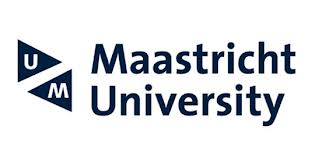

# Faculty of Science and Engineering - Department of Advanced Computer Sciences
# Course Advanced Natural Language Processing - Tutorial Tokenization

⏱️ **Estimated time:** 1.6 hours – 3.5 hours


By Jan Scholtes


---

Version 2026-2027

---

Welcome to the tutorial on Abstracting and Machine Translation. In this notebook we will explore traditional and modern methods for text summarization and machine translation.

For summarization, we start with extractive methods (TextRank, TF-IDF scoring, LSA) and then move to abstractive methods using Pegasus (an encoder-decoder model). For machine translation, we examine statistical methods (IBM Model 1) and then transformer-based neural approaches (Helsinki-NLP models).

For this notebook we would need our GPU accelerator. Make sure you have selected the GPU runtime in Google Colab (Runtime > Change Runtime Type > T4 GPU).

## Learning Goals

After completing this tutorial, you will be able to:

- **Understand** the difference between extractive and abstractive text summarization.
- **Apply** TextRank, TF-IDF scoring, and LSA for extractive summarization.
- **Use** Pegasus (encoder-decoder) for abstractive summarization and understand its limitations.
- **Compare** encoder-decoder vs decoder-only architectures for summarization tasks.
- **Understand** the IBM statistical machine translation models (Models 1-5).
- **Work with** word-level alignments and train IBM Model 1 for translation.
- **Use** transformer-based models (Helsinki-NLP) for neural machine translation.
- **Compare** statistical and neural approaches to machine translation using BLEU metrics.

# Extractive Summarization

Extractive text summarization ‘extracts’ notable information from the large corpora of text provided and organizes them into clear and concise summaries.

In Extractive Summarization, we identify essential phrases or sentences from the original text and extract only these phrases from the text. These extracted sentences would be the summary.

Extractive text summarization is the most common method used by automatic text summarizers.

Hereunder is a tutorial form colab: (https://colab.research.google.com/github/dipanjanS/nlp_workshop_odsc19/blob/master/Module05%20-%20NLP%20Applications/Project06%20-%20Text%20Summarization.ipynb)



In [ ]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')



Now let's load a text to summarize:

In [ ]:
DOCUMENT = """
The Elder Scrolls V: Skyrim is an action role-playing video game developed by Bethesda Game Studios
and published by Bethesda Softworks. It is the fifth main installment in The Elder Scrolls series,
following The Elder Scrolls IV: Oblivion.
The game's main story revolves around the player character's quest to defeat Alduin the World-Eater,
a dragon who is prophesied to destroy the world. The game is set 200 years after the events of Oblivion
and takes place in the fictional province of Skyrim. Over the course of the game, the player completes
quests and develops the character by improving skills. The game continues the open-world tradition of
its predecessors by allowing the player to travel anywhere in the game world at any time, and to ignore
or postpone the main storyline indefinitely.
The team opted for a unique and more diverse open world than Oblivion's Imperial Province of Cyrodiil,
which game director and executive producer Todd Howard considered less interesting by comparison.
The game was released to critical acclaim, with reviewers particularly mentioning the character advancement
and setting, and is considered to be one of the greatest video games of all time.


The Elder Scrolls V: Skyrim is an action role-playing game, playable from either a first or
third-person perspective. The player may freely roam over the land of Skyrim which is an open world
environment consisting of wilderness expanses, dungeons, cities, towns, fortresses, and villages.
Players may navigate the game world more quickly by riding horses or by utilizing a fast-travel system
which allows them to warp to previously discovered locations. The game's main quest can be completed or
ignored at the player's preference after the first stage of the quest is finished. However, some quests
rely on the main storyline being at least partially completed. Non-player characters (NPCs) populate the
world and can be interacted with in a number of ways: the player may engage them in conversation,
marry an eligible NPC, kill them or engage in a nonlethal "brawl". The player may
choose to join factions which are organized groups of NPCs — for example, the Dark Brotherhood, a band
of assassins. Each of the factions has an associated quest path to progress through. Each city and town
in the game world has jobs that the player can engage in, such as farming.

Players have the option to develop their character. At the beginning of the game, players create
their character by selecting their sex and choosing between one of several races including humans,
orcs, elves, and anthropomorphic cat or lizard-like creatures and then customizing their character's
appearance. Over the course of the game, players improve their character's skills which are numerical
representations of their ability in certain areas. There are eighteen skills divided evenly among the
three schools of combat, magic, and stealth. When players have trained skills enough to meet the
required experience, their character levels up. Health is depleted primarily when the player
takes damage and the loss of all health results in death. Magicka is depleted by the use of spells,
certain poisons and by being struck by lightning-based attacks. Stamina determines the player's
effectiveness in combat and is depleted by sprinting, performing heavy "power attacks"
and being struck by frost-based attacks. Skyrim is the first entry in The Elder Scrolls to
include dragons in the game's wilderness. Like other creatures, dragons are generated randomly in
the world and will engage in combat with NPCs, creatures and the player. Some dragons may attack
cities and towns when in their proximity. The player character can absorb the souls of dragons
in order to use powerful spells called "dragon shouts" or "Thu'um". A regeneration
period limits the player's use of shouts in gameplay.

Skyrim is set around 200 years after the events of The Elder Scrolls IV: Oblivion, although it is
not a direct sequel. The game takes place in Skyrim, a province of the Empire on the continent of
Tamriel, amid a civil war between two factions: the Stormcloaks, led by Ulfric Stormcloak, and the
Imperial Legion, led by General Tullius. The player character is a Dragonborn, a mortal born with
the soul and power of a dragon. Alduin, a large black dragon who returns to the land after being
lost in time, serves as the game's primary antagonist. Alduin is the first dragon created by Akatosh,
one of the series' gods, and is prophesied to destroy and consume the world.
"""

In [ ]:
import re

DOCUMENT = re.sub(r'\n|\r', ' ', DOCUMENT)
DOCUMENT = re.sub(r' +', ' ', DOCUMENT)
DOCUMENT = DOCUMENT.strip()

We will use TextRank for summarization (https://aclanthology.org/W04-3252/)

In [ ]:
import importlib, subprocess, sys
if importlib.util.find_spec('summa') is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "summa"])
from summa.summarizer import summarize

print(summarize(DOCUMENT, ratio=0.2, split=False))

In [ ]:
sentences = nltk.sent_tokenize(DOCUMENT)
len(sentences)

TextRank uses the following process:

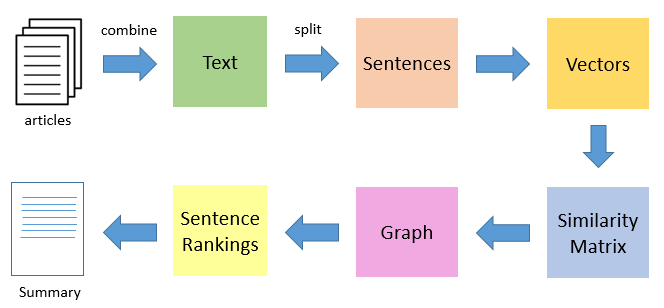

Tokenize and extract sentences from the document to be summarized.

Decide on the number of sentences, k, that we want in the final summary

Build a document-term feature matrix using weights like TF-IDF or Bag of Words.
Compute a document similarity matrix by multiplying the matrix by its transpose.

Use these documents (sentences in our case) as the vertices and the similarities between each pair of documents as the weight or score coefficient we talked about earlier and feed them to the PageRank algorithm.

Get the score for each sentence.

Rank the sentences based on score and return the top k sentences.

Here under you can try these steps one by one:

##Basic Text Processing

In [ ]:
import numpy as np

stop_words = nltk.corpus.stopwords.words('english')

def normalize_document(doc):
    # lower case and remove special characters\whitespaces
    doc = re.sub(r'[^a-zA-Z\s]', '', doc, re.I|re.A)
    doc = doc.lower()
    doc = doc.strip()
    # tokenize document
    tokens = nltk.word_tokenize(doc)
    # filter stopwords out of document
    filtered_tokens = [token for token in tokens if token not in stop_words]
    # re-create document from filtered tokens
    doc = ' '.join(filtered_tokens)
    return doc

normalize_corpus = np.vectorize(normalize_document)

norm_sentences = normalize_corpus(sentences)
norm_sentences[:3]

## Text Representation with Feature Engineering

We will be vectorizing our normalized sentences using the TF-IDF feature engineering scheme. We keep things simple and don’t filter out any words based on document frequency. But feel free to try that out and maybe even leverage n-grams as features.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

tv = TfidfVectorizer(min_df=0., max_df=1., use_idf=True)
dt_matrix = tv.fit_transform(norm_sentences)
dt_matrix = dt_matrix.toarray()

vocab = tv.get_feature_names_out()
td_matrix = dt_matrix.T
print(td_matrix.shape)
pd.DataFrame(np.round(td_matrix, 2), index=vocab).head(10)

## Latent Semantic Analysis
Here, we summarize our game description by utilizing document sentences. The terms in each sentence of the document have been extracted to form the term-document matrix, which we observed in the previous cell.

We apply low-rank Singular Value Decomposition to this matrix. The core principle behind Latent Semantic Analysis (LSA) is that in any document, there exists a latent structure among terms that are related contextually and hence should also be correlated in the same singular space.

The main idea in our implementation is to use SVD (recall M = USVT) so that U and V are the orthogonal matrices and S is the diagonal matrix, which can also be represented as a vector of the singular values.

The original matrix can be represented as a term-document matrix where the rows are terms and each column is a document, i.e., a sentence from our document in this case. The values can be any type of weighting like Bag of Words model-based frequencies, TF-IDFs, or binary occurrences.

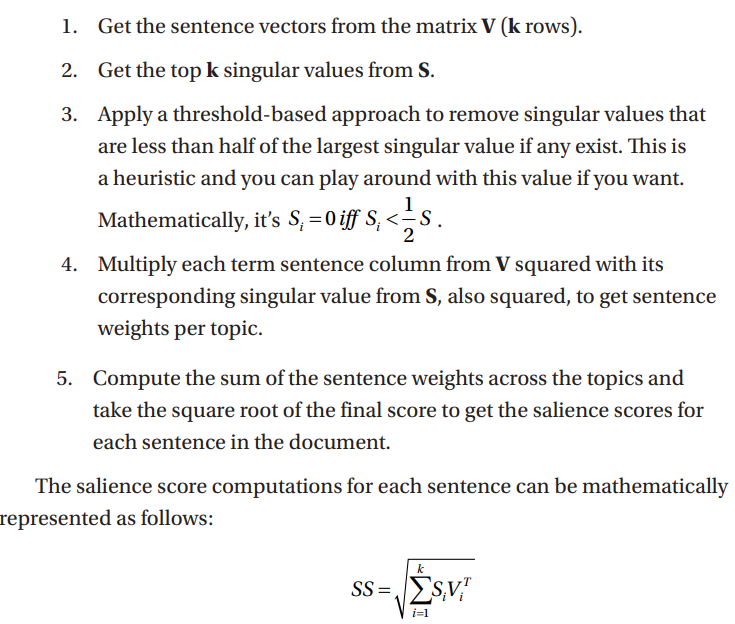



In [ ]:
from scipy.sparse.linalg import svds

def low_rank_svd(matrix, singular_count=2):
    u, s, vt = svds(matrix, k=singular_count)
    return u, s, vt

In [ ]:
num_sentences = 8
num_topics = 3

u, s, vt = low_rank_svd(td_matrix, singular_count=num_topics)
print(u.shape, s.shape, vt.shape)
term_topic_mat, singular_values, topic_document_mat = u, s, vt

In [ ]:
# remove singular values below threshold
sv_threshold = 0.5
min_sigma_value = max(singular_values) * sv_threshold
singular_values[singular_values < min_sigma_value] = 0

In [ ]:
salience_scores = np.sqrt(np.dot(np.square(singular_values),
                                 np.square(topic_document_mat)))
salience_scores

In [ ]:
top_sentence_indices = (-salience_scores).argsort()[:num_sentences]
top_sentence_indices.sort()

In [ ]:
print('\n'.join(np.array(sentences)[top_sentence_indices]))

## Build Similarity Matrix

In [ ]:
similarity_matrix = np.matmul(dt_matrix, dt_matrix.T)
print(similarity_matrix.shape)
np.round(similarity_matrix, 3)

## Build Similarity Graph


In [ ]:
import networkx

similarity_graph = networkx.from_numpy_array(similarity_matrix)
similarity_graph

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(12, 6))
networkx.draw_networkx(similarity_graph, node_color='lime')

## Now Find the most important Sentences

In [ ]:
scores = networkx.pagerank(similarity_graph)
ranked_sentences = sorted(((score, index) for index, score
                                            in scores.items()),
                          reverse=True)
ranked_sentences[:10]

In [ ]:
top_sentence_indices = [ranked_sentences[index][1]
                        for index in range(num_sentences)]
top_sentence_indices.sort()

In [ ]:
print('\n'.join(np.array(sentences)[top_sentence_indices]))

And "voila": the same summary as above!

# Abstractive Summarization

Abstractive text summarization generates real sentences from the entirety of the text provided. It rewrites large amounts of text by creating acceptable representations, which is further processed and summarized by natural language processing.

This method uses a statitical or large (deep learning) language model to generate such sentences.

It generates new sentences from the original text in the abstractive summarization approach. So, sentences generated through this abstractive summarization might not even be present in the original text.

Here is a short tutorial based on a script from HuggingFace.

Let's install transformers:

In [ ]:
import importlib, subprocess, sys
to_install = [p for p, m in [('transformers', 'transformers'), ('sentencepiece', 'sentencepiece')]
              if importlib.util.find_spec(m) is None]
if to_install:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *to_install])


**Importing and configuring the Pegasus model**

In [ ]:
import os
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
import transformers
transformers.logging.set_verbosity_error()
from datasets import disable_progress_bar
disable_progress_bar()
from transformers import PegasusForConditionalGeneration, PegasusTokenizer

In [ ]:
tokenizer_model = PegasusTokenizer.from_pretrained("google/pegasus-xsum")

In [ ]:
loaded_model = PegasusForConditionalGeneration.from_pretrained("google/pegasus-xsum")

**Performing abstractive summarization **

In [ ]:
text = """Hugging Face is a great open-source library that is doing powerful work in the Natural Language Processing (NLP) space.
The library has a bunch of pre-trained models which you can leverage or fine-tune.

The library has many models including BERT and GPT-2 models that perform various tasks, but for our purpose, we’ll be leveraging the pre-trained language pipeline.
Rather than going ahead and training a huge language model such as GPT-2 with 1.5 billion parameters, one can leverage the ML pipeline instead."""

In [ ]:
tokens = tokenizer_model(text, truncation=True, padding="longest", return_tensors="pt")

In [ ]:
tokens

In [ ]:
summary = loaded_model.generate(**tokens)

In [ ]:
summary[0]

In [ ]:
tokenizer_model.decode(summary[0])

Or let's take the text we used for the Extractive Summarization approach:

In [ ]:
text = """"The Elder Scrolls V: Skyrim is an action role-playing video game developed by Bethesda Game Studios
and published by Bethesda Softworks. It is the fifth main installment in The Elder Scrolls series,
following The Elder Scrolls IV: Oblivion.
The game's main story revolves around the player character's quest to defeat Alduin the World-Eater,
a dragon who is prophesied to destroy the world. The game is set 200 years after the events of Oblivion
and takes place in the fictional province of Skyrim. Over the course of the game, the player completes
quests and develops the character by improving skills. The game continues the open-world tradition of
its predecessors by allowing the player to travel anywhere in the game world at any time, and to ignore
or postpone the main storyline indefinitely.
The team opted for a unique and more diverse open world than Oblivion's Imperial Province of Cyrodiil,
which game director and executive producer Todd Howard considered less interesting by comparison.
The game was released to critical acclaim, with reviewers particularly mentioning the character advancement
and setting, and is considered to be one of the greatest video games of all time.


The Elder Scrolls V: Skyrim is an action role-playing game, playable from either a first or
third-person perspective. The player may freely roam over the land of Skyrim which is an open world
environment consisting of wilderness expanses, dungeons, cities, towns, fortresses, and villages.
Players may navigate the game world more quickly by riding horses or by utilizing a fast-travel system
which allows them to warp to previously discovered locations. The game's main quest can be completed or
ignored at the player's preference after the first stage of the quest is finished. However, some quests
rely on the main storyline being at least partially completed. Non-player characters (NPCs) populate the
world and can be interacted with in a number of ways: the player may engage them in conversation,
marry an eligible NPC, kill them or engage in a nonlethal "brawl". The player may
choose to join factions which are organized groups of NPCs — for example, the Dark Brotherhood, a band
of assassins. Each of the factions has an associated quest path to progress through. Each city and town
in the game world has jobs that the player can engage in, such as farming.

Players have the option to develop their character. At the beginning of the game, players create
their character by selecting their sex and choosing between one of several races including humans,
orcs, elves, and anthropomorphic cat or lizard-like creatures and then customizing their character's
appearance. Over the course of the game, players improve their character's skills which are numerical
representations of their ability in certain areas. There are eighteen skills divided evenly among the
three schools of combat, magic, and stealth. When players have trained skills enough to meet the
required experience, their character levels up. Health is depleted primarily when the player
takes damage and the loss of all health results in death. Magicka is depleted by the use of spells,
certain poisons and by being struck by lightning-based attacks. Stamina determines the player's
effectiveness in combat and is depleted by sprinting, performing heavy "power attacks"
and being struck by frost-based attacks. Skyrim is the first entry in The Elder Scrolls to
include dragons in the game's wilderness. Like other creatures, dragons are generated randomly in
the world and will engage in combat with NPCs, creatures and the player. Some dragons may attack
cities and towns when in their proximity. The player character can absorb the souls of dragons
in order to use powerful spells called "dragon shouts" or "Thu'um". A regeneration
period limits the player's use of shouts in gameplay.

Skyrim is set around 200 years after the events of The Elder Scrolls IV: Oblivion, although it is
not a direct sequel. The game takes place in Skyrim, a province of the Empire on the continent of
Tamriel, amid a civil war between two factions: the Stormcloaks, led by Ulfric Stormcloak, and the
Imperial Legion, led by General Tullius. The player character is a Dragonborn, a mortal born with
the soul and power of a dragon. Alduin, a large black dragon who returns to the land after being
lost in time, serves as the game's primary antagonist. Alduin is the first dragon created by Akatosh,
one of the series' gods, and is prophesied to destroy and consume the world."""

In [ ]:
tokens = tokenizer_model(text, truncation=True, padding="longest", return_tensors="pt")
summary = loaded_model.generate(**tokens)

In [ ]:
tokenizer_model.decode(summary[0])


# Machine Translation

We will now move on to Machine Translation. Machine translation is a typical encoding-decoding task where a text-phrase from the source language (e.g. English) is translated to a targer language (e.g. German). The original Transformer models (T5) from the paper "Attention is all you need" discussed Machine Translation as the NLP application.

Machine Translation is complex, both allignment between words in a source and target language can differ enormously. Attention is the mechanism to deal with this.

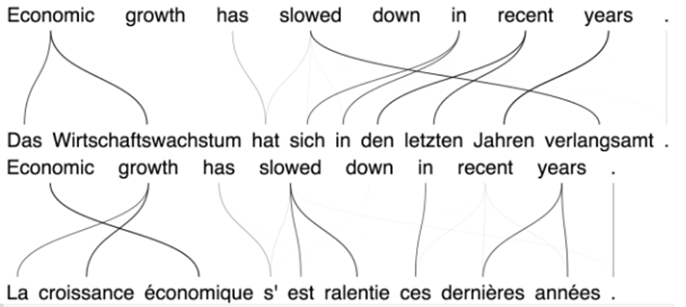

We will explain you this in more detail by first looking at some traditional rules-based and statistical models and then move on to the Transformers using Multi-Headed Self-Attention.

#Statistical Machine Translation

In [ ]:
import nltk
nltk.download('comtrans')
from nltk.corpus import comtrans

Next, import a word-level alligned corpus for English-French from NLTK and print the content of the corpus

In [ ]:
words = comtrans.words("alignment-en-fr.txt")

In [ ]:
len(words)

Now, we can print the sentence and investigate the allignments for English-French.

In [ ]:
for word in words[:20]:
  print(word)
als = comtrans.aligned_sents('alignment-en-fr.txt')[0]
als

Aligned sentences are simply a mapping between words in a sentence:

You can see how the words and the allignments work internally. In the first sentence allignment is exactly the same for Frenc and English. In the second sentence, you see the allignment changing with (6,5), which is due to a different word order for the different  grammatical structures in English and French"of the" and "du". This continues further on. At the end you see a larger difference in allignments (39,33).

In [ ]:
comtrans.aligned_sents('alignment-en-fr.txt')

Check total number of alligned sentences.

In [ ]:
len(comtrans.aligned_sents('alignment-en-fr.txt'))

In [ ]:
print(" ".join(als.words))

In [ ]:
print(" ".join(als.mots))

In [ ]:
als.alignment

Usually we look at them from the perspective of a source to a target language, but they are easily inverted:

In [ ]:
als.invert()

We can create new allignments, but these need to be in the correct range of the corresponding sentences: **THE FOLLOWING CODE GIVES YOU AN ERROR, THAT IS THE OBJECTIVE !!!!!**

In [ ]:
from nltk.translate import Alignment, AlignedSent
als = AlignedSent(['Reprise', 'de', 'la', 'session'], ['Resumption', 'of', 'the', 'session'], Alignment([(0, 0), (1, 4), (2, 1), (3, 3)]))

So, we need to make sure the allignment is in the correct range to prevent the "IndexError: Alignment is outside boundary of mots"  error.

You can set alignments with any sequence of tuples, so long as the first two indexes of the tuple are the alignment indices:

In [ ]:
als.alignment = Alignment([(0, 0), (1, 1), (2, 2, "boat"), (3, 3, False, (1,2))])

In [ ]:
Alignment([(0, 0), (1, 1), (2, 2, "boat"), (3, 3, False, (1,2))])

Now, we can train our model using a allignment model, in this case EM for IBM Model 1 from NLTK.

In [ ]:
from nltk.translate import IBMModel1
corpus = [AlignedSent(['the', 'house'], ['das', 'Haus']), AlignedSent(['the', 'book'], ['das', 'Buch']), AlignedSent(['a', 'book'], ['ein', 'Buch'])]
em_ibm1 = IBMModel1(corpus, 20)

# Now print a few word combinations and their probabilities
#
print(round(em_ibm1.translation_table['the']['das'], 1))

In [ ]:
print(round(em_ibm1.translation_table['book']['das'], 1))

In [ ]:
print(round(em_ibm1.translation_table['house']['das'], 1))

In [ ]:
print(round(em_ibm1.translation_table['the']['Buch'], 1))

In [ ]:
print(round(em_ibm1.translation_table['book']['Buch'], 1))

And using an NLTK corpus. We train on only 1000 sentences, which you will see is already quit slow:

In [ ]:
com_ibm1 = IBMModel1(comtrans.aligned_sents()[:1000], 20)
print(round(com_ibm1.translation_table['bitte']['Please'], 1))
print(round(com_ibm1.translation_table['Sitzungsperiode']['session'], 1))


IBM has developed 5 different statistical models (5 most advanced) that are part of NLTK. You can read more here: https://www.nltk.org/api/nltk.translate.html

The IBM models 1 to 5, developed by IBM in the 1990s, laid the foundation for statistical machine translation. IBM still owns many patents in the field of Machine Translation.



1.   IBM Model 1: This is the simplest model, where the main focus is on word-to-word translation probabilities without considering word order. It assumes that each word in the source sentence translates to a word in the target sentence independently, and all alignments have equal probability.

2.   IBM Model 2: This model improves on Model 1 by introducing alignment probabilities that take the position of words into account. It assigns a probability for a word in the source sentence aligning to a specific position in the target sentence, thus providing a basic handling of word order.

3.   IBM Model 3: This model incorporates the concept of fertility, which is the number of target words produced by each source word. It also introduces a distortion parameter that models the movement of words from their original positions, allowing for more flexible word reordering between languages.

4.   IBM Model 4: Building on Model 3, Model 4 enhances the distortion model to account for more complex alignment patterns, particularly in handling long-distance reordering of words. It introduces new parameters to better manage how groups of words move relative to each other.

5.   IBM Model 5: The final model refines the concepts of fertility and distortion from Model 4 by addressing issues related to alignment deficiencies (e.g., multiple words aligning to the same position). It ensures a more coherent and mathematically consistent translation alignment.

These models collectively paved the way for more sophisticated machine translation approaches by incrementally adding complexity and handling more nuanced translation features. However, training required a lot of (manually) annotated training data such as (multi-word) allignments.

## Demonstration: English-French Translation with IBM Model 1

The following code demonstrates training IBM Model 1 on the English-French `comtrans` corpus, translating 50 sentences, and computing BLEU scores. This serves as a worked example for the exercises at the end of this tutorial.

In [ ]:
from nltk.corpus import comtrans
from nltk.translate import IBMModel1, AlignedSent

aligned_sentences = comtrans.aligned_sents('alignment-en-fr.txt')

# Create a training corpus by taking a subset of these aligned sentences
training_corpus = aligned_sentences[:1000]

# Train an IBMModel1 using this training corpus with 20 iterations
ibm1_model = IBMModel1(training_corpus, 20)

print("IBM Model 1 trained successfully with the first 1000 aligned sentences.")

In [ ]:
sentences_to_translate = aligned_sentences[:50]

candidate_translations = []
reference_translations = []

for i, aligned_sent in enumerate(sentences_to_translate):
    english_sentence = " ".join(aligned_sent.words)

    # Store the reference French sentence
    reference_translations.append([aligned_sent.mots]) # corpus_bleu expects a list of lists of references

    # Translate the English sentence word by word
    french_translation = []
    for english_word in aligned_sent.words:
        # Find the most probable French translation for the English word
        # If the word is not in the translation table, keep the English word or use a placeholder
        if english_word in ibm1_model.translation_table:
            most_probable_french_word = max(ibm1_model.translation_table[english_word].items(), key=lambda item: item[1])[0]
            french_translation.append(most_probable_french_word)
        else:
            # Fallback for words not in the translation table
            french_translation.append(f'[{english_word}]') # Using brackets to indicate untranslated words

    translated_french_sentence = " ".join(french_translation)

    candidate_translations.append(french_translation) # Store the candidate translation

    print(f"Original English ({i+1}): {english_sentence}")
    print(f"Translated French ({i+1}): {translated_french_sentence}")
    print("-" * 50)


We can now also calculate the final BLEU scores for the translations above.

In [ ]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

# Calculate BLEU-1 score
# weights=(1, 0, 0, 0) means only consider unigrams (BLEU-1)
# We use SmoothingFunction().method1 to handle cases where unigrams might be zero
bleu_1_score = corpus_bleu(reference_translations, candidate_translations, weights=(1, 0, 0, 0), smoothing_function=SmoothingFunction().method1)

# Calculate BLEU-2 score for IBM Model 1 translations
bleu_2_score = corpus_bleu(reference_translations, candidate_translations, weights=(0.5, 0.5, 0, 0), smoothing_function=SmoothingFunction().method1)

# Calculate BLEU-3 score for IBM Model 1 translations
bleu_3_score = corpus_bleu(reference_translations, candidate_translations, weights=(0.33, 0.33, 0.33, 0), smoothing_function=SmoothingFunction().method1)

print(f"Total Average BLEU-1 Score for IBM Model 1: {bleu_1_score:.4f}")
print(f"Total Average BLEU-2 Score for IBM Model 1: {bleu_2_score:.4f}")
print(f"Total Average BLEU-3 Score for IBM Model 1: {bleu_3_score:.4f}")

# Machine Translation with a RNN or a LSTM and attention

For many years, popular machine translation model were based on either a RNN or a LSTM. The idea is to first translate the text andsource/target language you used for the IBM model now with a RNN/ LSTM and then investigate the effect of attention. However, since the success of the transformer models, LSTM is a closed book. Most models disappeared and the few still available are no longer manintained. So, we decided to remove this from the tutorial.



# Transformer-based Machine Translation

The Transformer Translation code hereunder is from: https://colab.research.google.com/drive/1RIcKVMVRcKVbhoyqpzy2s1KSchS4XJX2?usp=sharing


In [ ]:
import importlib, subprocess, sys
to_install = [p for p, m in [('transformers', 'transformers'), ('sentencepiece', 'sentencepiece')]
              if importlib.util.find_spec(m) is None]
if to_install:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *to_install])


In [ ]:
from transformers import *

In [ ]:
# source & destination languages
src = "en"
dst = "de"

task_name = f"translation_{src}_to_{dst}"
model_name = f"Helsinki-NLP/opus-mt-{src}-{dst}"

translator  = pipeline(task_name, model=model_name, tokenizer=model_name)

In [ ]:
translator("You're a genius.")[0]["translation_text"]

In [ ]:
article = """
Albert Einstein ( 14 March 1879 – 18 April 1955) was a German-born theoretical physicist, widely acknowledged to be one of the greatest physicists of all time.
Einstein is best known for developing the theory of relativity, but he also made important contributions to the development of the theory of quantum mechanics.
Relativity and quantum mechanics are together the two pillars of modern physics.
His mass–energy equivalence formula E = mc2, which arises from relativity theory, has been dubbed "the world's most famous equation".
His work is also known for its influence on the philosophy of science.
He received the 1921 Nobel Prize in Physics "for his services to theoretical physics, and especially for his discovery of the law of the photoelectric effect", a pivotal step in the development of quantum theory.
His intellectual achievements and originality resulted in "Einstein" becoming synonymous with "genius"
"""

In [ ]:
translator(article)[0]["translation_text"]

In [ ]:
def get_translation_model_and_tokenizer(src_lang, dst_lang):
  """
  Given the source and destination languages, returns the appropriate model
  See the language codes here: https://developers.google.com/admin-sdk/directory/v1/languages
  For the 3-character language codes, you can google for the code!
  """
  # construct our model name
  model_name = f"Helsinki-NLP/opus-mt-{src_lang}-{dst_lang}"
  # initialize the tokenizer & model
  tokenizer = AutoTokenizer.from_pretrained(model_name)
  model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
  # return them for use
  return model, tokenizer

In [ ]:
# source & destination languages
src = "en"
dst = "zh"

model, tokenizer = get_translation_model_and_tokenizer(src, dst)

In [ ]:
# encode the text into tensor of integers using the appropriate tokenizer
inputs = tokenizer.encode(article, return_tensors="pt", max_length=512, truncation=True)
print(inputs)

In [ ]:
# generate the translation output using greedy search
greedy_outputs = model.generate(inputs)
# decode the output and ignore special tokens
print(tokenizer.decode(greedy_outputs[0], skip_special_tokens=True))

In [ ]:
# generate the translation output using beam search
beam_outputs = model.generate(inputs, num_beams=3)
# decode the output and ignore special tokens
print(tokenizer.decode(beam_outputs[0], skip_special_tokens=True))

If you do not read / understand Chineese, you can try this for a language that you do speak, to understand the difference between the Greedy and Beam Search. We have also seen this in GPT-3 in the previous lecture / tutorial.  

In [ ]:
# let's change target language
src = "en"
dst = "ar"

# get en-ar model & tokenizer
model, tokenizer = get_translation_model_and_tokenizer(src, dst)

In [ ]:
# yet another example
text = "It can be severe, and has caused millions of deaths around the world as well as lasting health problems in some who have survived the illness."
# tokenize the text
inputs = tokenizer.encode(text, return_tensors="pt", max_length=512, truncation=True)
# this time we use 5 beams and return 5 sequences and we can compare!
beam_outputs = model.generate(
    inputs,
    num_beams=5,
    num_return_sequences=5,
    early_stopping=True,
)
for i, beam_output in enumerate(beam_outputs):
  print(tokenizer.decode(beam_output, skip_special_tokens=True))
  print("="*50)

---

# Exercises

Complete the following four exercises. Write your code in the code cells and your explanations in the markdown cells. Use the `### BEGIN SOLUTION` and `### END SOLUTION` markers to indicate your solutions.

## Exercise A1: Extractive Summarization (15 points)

**a)** (5 points - code) A TF-IDF sentence-scoring summarizer is provided below as an alternative to TextRank and LSA from the tutorial. Run it on the `DOCUMENT` with k=3 sentences and compare with the tutorial methods.

**b)** (10 points - explanation) Compare the three approaches (TF-IDF, TextRank, LSA) — which produces the best summary and why? What are the strengths and limitations of extractive summarization?

In [ ]:
# TF-IDF summarizer scaffold (provided)
def tfidf_summarizer(text, k=3):
    sents = nltk.sent_tokenize(text)
    norm_sents = [normalize_document(s) for s in sents]
    tv = TfidfVectorizer(min_df=0., max_df=1., use_idf=True)
    tfidf_matrix = tv.fit_transform(norm_sents)
    sentence_scores = tfidf_matrix.mean(axis=1).A1.flatten()
    top_indices = sorted(np.argsort(sentence_scores)[-k:])
    return '\n'.join([sents[i] for i in top_indices])

### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

In [ ]:
# Tests for A1 (5 points)
assert 'tfidf_summarizer' in dir(), "tfidf_summarizer function must be defined"
result = tfidf_summarizer(DOCUMENT, k=3)
assert isinstance(result, str), "Summarizer must return a string"
assert len(result) > 0, "Summary must not be empty"
assert len(result) < len(DOCUMENT), "Summary must be shorter than original"
print("All A1 tests passed!")

**b) Write your analysis below:**

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## Exercise A2: Abstractive Summarization with Pegasus (15 points)

**a)** (5 points - code) The scaffold below generates Pegasus summaries at different lengths. Run it and optionally try an alternative model (e.g., `facebook/bart-large-cnn`).

**b)** (10 points - explanation) How do encoder-decoder models (Pegasus) differ from decoder-only models (GPT) for summarization? Compare: summary quality, length control, and hallucination tendency.

In [ ]:
# Pegasus length variation scaffold (provided)
length_configs = [(64, 10), (128, 30), (256, 60)]

### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

In [ ]:
# Tests for A2 (5 points)
assert 'decoded' in dir(), "At least one summary must be generated"
assert len(decoded) > 0, "Summary must not be empty"
print("A2 tests passed!")

**b) Write your comparison below:**

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## Exercise A3: IBM Model 1 Translation Analysis (15 points)

**a)** (5 points - code) The scaffold below computes per-sentence BLEU-1 scores for the 50 IBM Model 1 translations from the tutorial and shows the best/worst. Run it and inspect the results.

**b)** (10 points - explanation) Why does IBM Model 1 produce poor translations? Which linguistic phenomena does it fail to handle? How do IBM Models 2-5 address these?

In [ ]:
# Per-sentence BLEU analysis scaffold (provided)
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
smoothing = SmoothingFunction().method1

### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

In [ ]:
# Tests for A3 (5 points)
assert 'per_sentence_scores' in dir(), "per_sentence_scores must be computed"
assert len(per_sentence_scores) == 50, "Must compute scores for all 50 sentences"
assert all(0 <= s <= 1 for _, s in per_sentence_scores), "BLEU scores must be between 0 and 1"
print("All A3 tests passed!")

**b) Write your analysis below:**

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## Exercise A4: Neural Machine Translation with Transformers (15 points)

**a)** (5 points - code) The scaffold below translates the same 50 sentences using the Helsinki-NLP Transformer model and computes BLEU scores. Run it and compare with IBM Model 1.

**b)** (10 points - explanation) Compare IBM Model 1 vs Transformer in a table. Explain why Transformers are better: what role do self-attention, cross-attention, and the decoder language model play?

In [ ]:
# Transformer translation scaffold (provided)
transformer_model_fr, transformer_tokenizer_fr = get_translation_model_and_tokenizer("en", "fr")

### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

In [ ]:
# Tests for A4 (5 points)
assert 'transformer_candidate_translations' in dir(), "Transformer translations must be computed"
assert len(transformer_candidate_translations) == 50, "Must translate all 50 sentences"
assert 't_bleu1' in dir(), "BLEU-1 score must be computed"
assert t_bleu1 > bleu_1_score, "Transformer BLEU-1 should be higher than IBM Model 1"
print(f"Transformer BLEU-1 ({t_bleu1:.4f}) > IBM Model 1 BLEU-1 ({bleu_1_score:.4f})")
print("All A4 tests passed!")

**b) Write your comparison below:**

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

---

## Take-Aways

1. **Extractive summarization** selects important sentences from the original text. Methods like TextRank (graph-based), TF-IDF scoring (statistical), and LSA (latent semantic) provide effective approaches. The key limitation is that extractive methods cannot paraphrase or combine information.

2. **Abstractive summarization** generates new text that captures the essence of the original. Encoder-decoder models like Pegasus are specifically designed for this task, while decoder-only models like GPT can also summarize through instruction following.

3. **Statistical machine translation** (IBM Models) uses word-level probability tables and alignment models. IBM Model 1 demonstrates the fundamental challenge: without word order, morphology, and fluency modeling, translations are largely incoherent.

4. **Neural machine translation** with Transformers achieves dramatically better results through contextual embeddings, attention-based alignment, and an integrated target language model. The architecture naturally handles reordering, morphology, and long-range dependencies.

5. **BLEU scores** provide a quantitative measure of translation quality by comparing n-gram overlap with reference translations, but they have limitations and may not fully capture semantic equivalence or fluency.